# Grover's Search Algorithm

**Goal:** Find a marked element in an unsorted list of $N = 2^n$ items using only $O(\sqrt{N})$ queries.

## Overview

Grover's algorithm achieves a quadratic speedup over classical search. The procedure:

1. Initialize all qubits in uniform superposition via Hadamard gates.
2. Repeat $\approx \frac{\pi}{4}\sqrt{N}$ times:
   - **Oracle** $Z_f$: flip the phase of the marked state $|w\rangle$.
   - **Diffusion** $D$: reflect about the uniform superposition (amplify the marked amplitude).
3. Measure to the marked state appears with high probability.

We'll demonstrate on **3 qubits** ($N = 8$), searching for the state $|101\rangle = |5\rangle$.


In [7]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt


## 1 — Build the Oracle

The oracle flips the phase of $|101\rangle$. This is a multi-controlled Z gate conditioned on
qubits 0 and 2 being $|1\rangle$ and qubit 1 being $|0\rangle$.


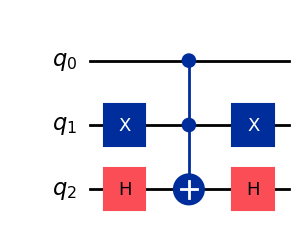

In [8]:
def grover_oracle(n, marked):
    """Phase oracle that flips |marked>."""
    qc = QuantumCircuit(n, name="Zf")
    # Flip qubits that should be |0> in the target state
    for i in range(n):
        if not (marked >> i) & 1:
            qc.x(i)
    # Multi-controlled Z = H-MCX-H on target qubit
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)
    # Undo flips
    for i in range(n):
        if not (marked >> i) & 1:
            qc.x(i)
    return qc.to_gate()

n_qubits = 3
marked_state = 5  # |101>
oracle_gate = grover_oracle(n_qubits, marked_state)

# Visualize the oracle sub-circuit
oracle_circ = QuantumCircuit(n_qubits)
oracle_circ.append(oracle_gate, range(n_qubits))
oracle_circ.decompose().draw("mpl", style="iqp")


## 2 — Build the Diffusion Operator

The diffusion operator $D = 2|s\rangle\langle s| - I$ reflects amplitudes about the mean.
In circuit form: $H^{\otimes n} \;(2|0\rangle\langle 0| - I)\; H^{\otimes n}$.


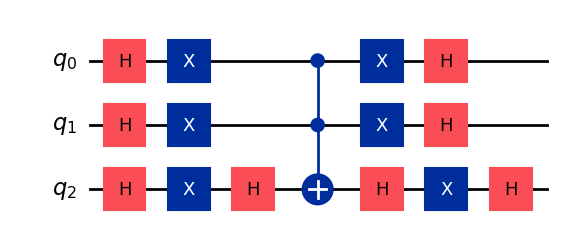

In [9]:
def diffusion_operator(n):
    """Grover diffusion operator on n qubits."""
    qc = QuantumCircuit(n, name="D")
    qc.h(range(n))
    qc.x(range(n))
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)
    qc.x(range(n))
    qc.h(range(n))
    return qc.to_gate()

diff_gate = diffusion_operator(n_qubits)

diff_circ = QuantumCircuit(n_qubits)
diff_circ.append(diff_gate, range(n_qubits))
diff_circ.decompose().draw("mpl", style="iqp")


## 3 — Assemble and Run Grover's Circuit

For $N = 8$, the optimal number of Grover iterations is
$\lfloor \frac{\pi}{4}\sqrt{8} \rfloor = 2$.


N = 8, optimal iterations = 2


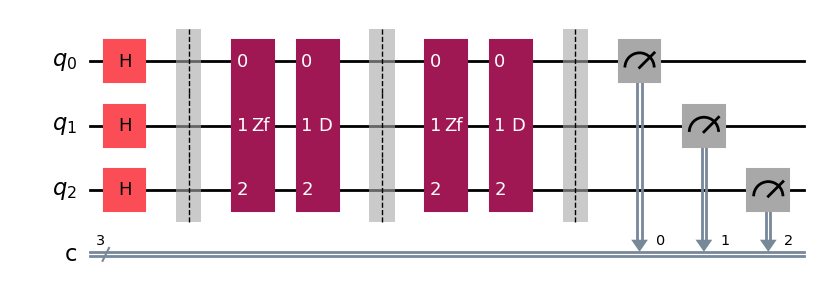

In [10]:
import math

N = 2 ** n_qubits
num_iterations = math.floor(math.pi / 4 * math.sqrt(N))
print(f"N = {N}, optimal iterations = {num_iterations}")

# Build full circuit
grover = QuantumCircuit(n_qubits, n_qubits)
grover.h(range(n_qubits))
grover.barrier()

for _ in range(num_iterations):
    grover.append(oracle_gate, range(n_qubits))
    grover.append(diff_gate, range(n_qubits))
    grover.barrier()

grover.measure(range(n_qubits), range(n_qubits))
grover.draw("mpl", style="iqp")


Searching for |101> = |5>
Top results: {'101': 3874, '110': 39, '010': 35, '001': 31}


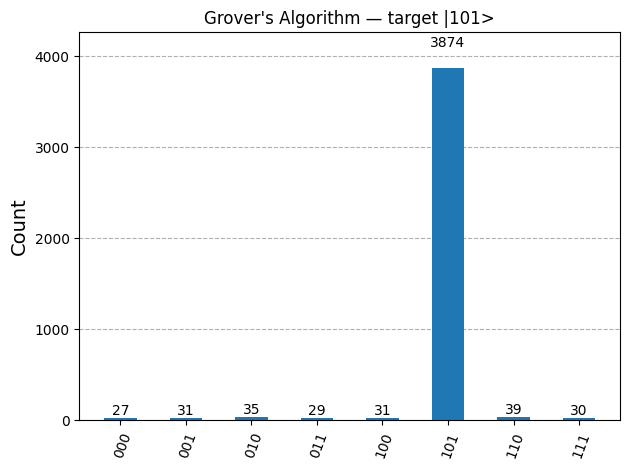

In [11]:
# Simulate
sim = AerSimulator()
compiled = transpile(grover, sim)
result = sim.run(compiled, shots=4096).result()
counts = result.get_counts()

print(f"Searching for |{marked_state:0{n_qubits}b}> = |{marked_state}>")
print(f"Top results: {dict(sorted(counts.items(), key=lambda x: -x[1])[:4])}")

plot_histogram(counts, title=f"Grover's Algorithm — target |{marked_state:0{n_qubits}b}>")


## Analysis

The marked state $|101\rangle$ dominates the measurement histogram with probability
$\approx 97\%$ after just 2 oracle queries. A classical search would need $O(N)$ queries on average.

**Key takeaway:** Grover's algorithm provides a provably optimal quadratic speedup for
unstructured search problems.
